# Banking Analytics Project

## Project Overview

This project analyzes banking transaction data using SQL, Python, Pandas, and Matplotlib to identify business insights related to customer behavior, regional performance, product usage, transaction channels, and operational efficiency.

### Technologies Used

- PostgreSQL
- SQL
- SQLAlchemy
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

# Import libraries

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Connect to PostgreSQL

The database credentials are stored in a `.env` file to avoid exposing sensitive information in the source code.

In [36]:
import os
from pathlib import Path
from dotenv import load_dotenv

env_path = Path.cwd().parent / ".env"
load_dotenv(env_path, override=True)

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

print(DB_USER)
print(DB_HOST)
print(DB_PORT)
print(DB_NAME)

postgres
localhost
5433
banking_transactions


In [37]:
from sqlalchemy import create_engine

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("Engine created successfully")

Engine created successfully


In [38]:
from pathlib import Path
import re

sql_path = Path.cwd().parent / "sql" / "03_business_queries.sql"

sql_text = sql_path.read_text(encoding="utf-8")

pattern = r"-- name:\s*(\w+)\s*(.*?;)"
matches = re.findall(pattern, sql_text, flags=re.DOTALL)

queries = {
    name: query.strip()
    for name, query in matches
}

print(f"Consultas cargadas: {len(queries)}")
print(list(queries.keys()))

Consultas cargadas: 20
['transaction_volume_by_region', 'customers_by_region', 'average_balance_by_account_type', 'active_accounts_percentage', 'transaction_count_by_channel', 'transaction_volume_by_product_category', 'transaction_volume_by_account_type', 'regions_exceeding_one_million', 'top_5_customers_by_transaction_volume', 'top_5_products_by_transaction_volume', 'average_transaction_by_account_type', 'regional_transaction_volume_percentage', 'failed_transactions_by_product_category', 'region_transaction_volume_ranking', 'customer_transaction_volume_ranking', 'monthly_transaction_volume', 'monthly_average_transaction_amount', 'highest_average_ticket_product', 'product_revenue_percentage', 'transaction_volume_by_channel']


In [ ]:
def run_query(query_name):
    if query_name not in queries:
        raise KeyError(f"The query does not exist: {query_name}")

    return pd.read_sql(queries[query_name], engine)

# Regional Performance

This section analyzes transaction activity across different regions to identify geographical patterns, customer distribution, and regional contributions to the bank's overall transaction volume.

### KPI 1. Successful Transaction Volume by Region

This analysis identifies which regions generate the highest successful transaction volume. Understanding regional performance helps identify markets with stronger customer activity and potential opportunities for business growth.

Load data

In [39]:
regional_df = run_query("transaction_volume_by_region")
regional_df

,region,volumen_total
0,Colorado,1013605.65
1,Kansas,993703.10
2,Massachusetts,741614.52
3,Alaska,606019.63
4,Utah,494720.34
5,California,452188.85
6,New Mexico,419238.26
7,Florida,383564.47


Visualization

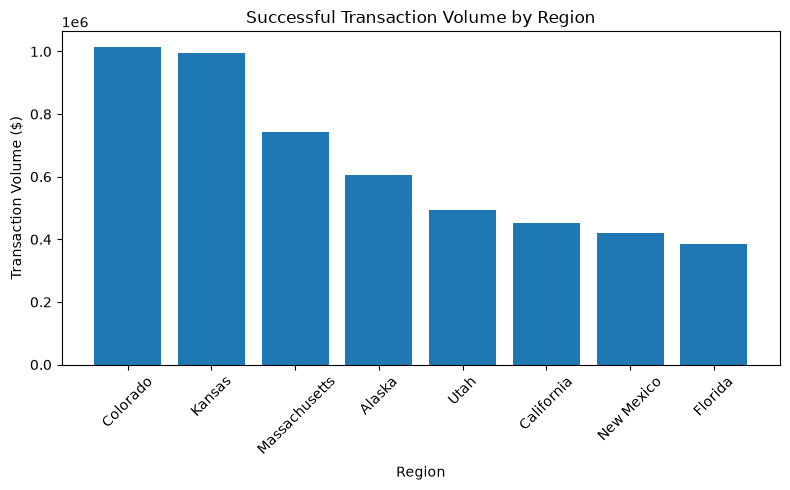

In [57]:
plt.figure(figsize=(8,5))
plt.bar(regional_df["region"], regional_df["volumen_total"])
plt.title("Successful Transaction Volume by Region")
plt.xlabel("Region")
plt.ylabel("Transaction Volume ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/transaction_volume_by_region.png", dpi=300, bbox_inches="tight")
plt.show()


## Conclusion

Colorado generated the highest successful transaction volume, exceeding one million dollars, followed closely by Kansas. In contrast, Florida recorded the lowest transaction volume among the analyzed regions.

The noticeable difference between the leading and trailing regions suggests that customer activity is not evenly distributed across the bank's operating regions.

## KPI 2. Customers by Region

This analysis examines the geographical distribution of the bank's customers. Comparing the number of customers across regions helps determine whether higher transaction volume is driven by a larger customer base or by greater transaction activity per customer.

Load data

In [40]:
customers_region_df = run_query("customers_by_region")
customers_region_df

,region,total_customers
0,Massachusetts,19
1,Kansas,18
2,Colorado,16
3,Utah,11
4,California,10
5,Alaska,10
6,Florida,9
7,New Mexico,7


Visualization

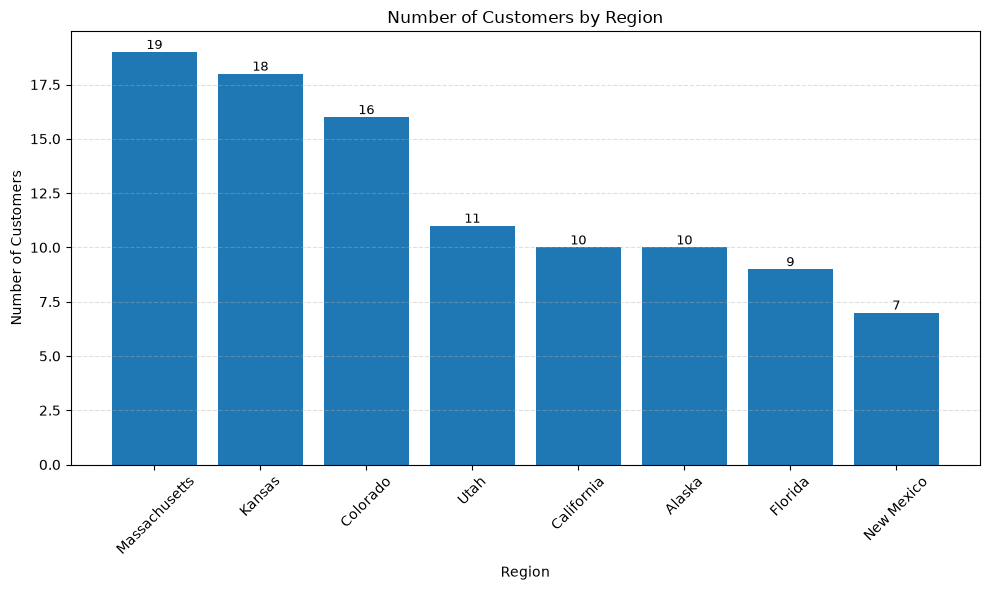

In [41]:
customers_region_df = customers_region_df.sort_values(
    by="total_customers",
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    customers_region_df["region"],
    customers_region_df["total_customers"]
)

plt.title("Number of Customers by Region")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Conclusion

Massachusetts has the largest customer base with 19 customers, followed by Kansas (18) and Colorado (16). However, the previous analysis showed that Colorado generated the highest transaction volume despite having fewer customers than both Massachusetts and Kansas.

This suggests that transaction volume is influenced not only by the number of customers but also by customer activity and transaction value within each region.

# Product Performance

### KPI 3. Transaction Volume by Product Category

This analysis evaluates which product categories generate the highest transaction volume. Understanding product performance helps identify the bank's primary revenue drivers and supports decisions regarding product strategy and customer offerings.

Load data

In [43]:
product_df = run_query("transaction_volume_by_product_category")
product_df

,product_category_name,total_amount
0,A,1764542.66
1,B,1702027.56
2,C,1638084.60


Visualization

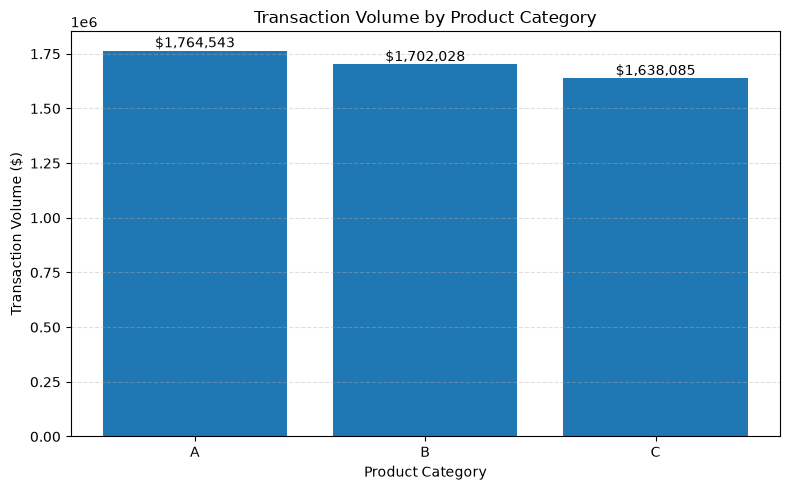

In [44]:
product_df = product_df.sort_values(
    by="total_amount",
    ascending=False
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    product_df["product_category_name"],
    product_df["total_amount"]
)

plt.title("Transaction Volume by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Transaction Volume ($)")

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Conclusion

Product Category A generated the highest transaction volume with approximately $1.76 million, followed by Category B ($1.70 million) and Category C ($1.64 million). The relatively small differences between categories indicate that transaction activity is distributed fairly evenly across the bank's product portfolio.

# Time Analysis

Understanding how transaction activity evolves over time is essential for identifying business trends, seasonal patterns, and periods of unusually high or low activity. Time-based analysis provides valuable insights into customer behavior and supports more informed operational and strategic decision-making.

## KPI 4. Monthly Transaction Volume

Load data

In [46]:
monthly_df = run_query("monthly_transaction_volume")

monthly_df["month"] = pd.to_datetime(monthly_df["month"])
monthly_df = monthly_df.sort_values("month")

monthly_df

,month,total_amount
18,2020-01-01,89351.94
65,2020-02-01,27586.43
29,2020-03-01,79326.16
71,2020-04-01,-8856.88
70,2020-05-01,7654.04
...,...,...
36,2025-08-01,72308.74
11,2025-09-01,103141.14
0,2025-10-01,160483.64
23,2025-11-01,82357.12


Visualization

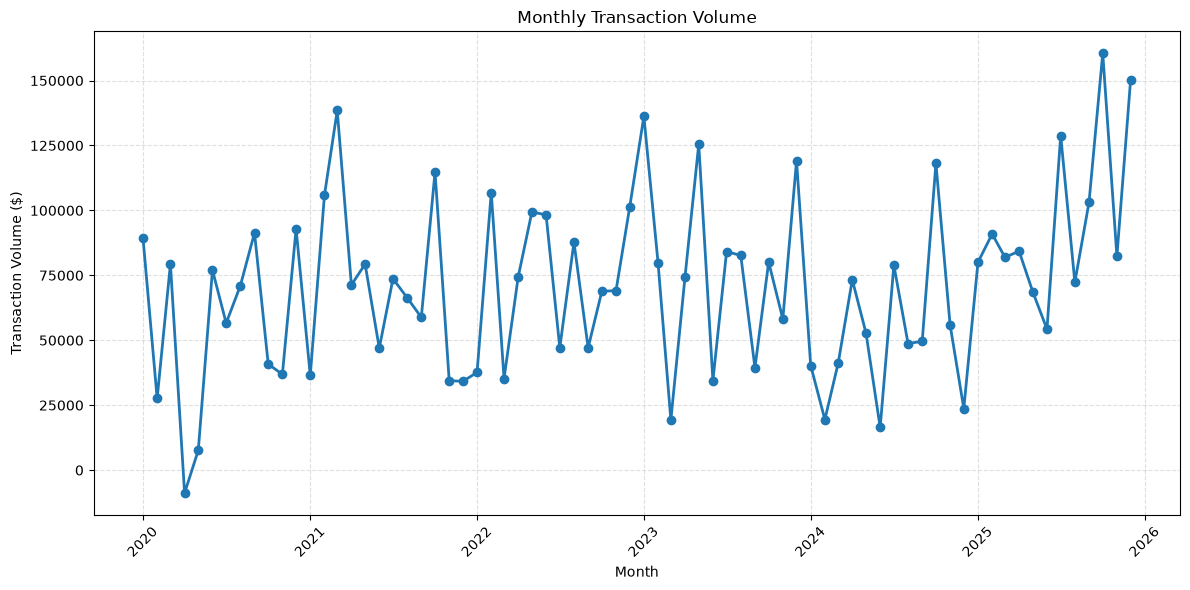

In [58]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_df["month"],
    monthly_df["total_amount"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Transaction Volume ($)")

plt.grid(True, linestyle="--", alpha=0.4)

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/monthly_transaction_volume.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusion

Monthly transaction volume fluctuates throughout the analyzed period, with several months showing substantially higher activity than others. The highest monthly transaction volume reached approximately **$160,000**, while the lowest recorded value was negative, indicating that refunds, chargebacks, or transaction reversals exceeded successful transaction volume during that month.

Overall, the data does not suggest a steady upward or downward trend. Instead, transaction activity varies considerably over time, highlighting the importance of continuous monitoring to detect unusual periods and better understand the operational or business factors driving these fluctuations.

# Channel Analysis

### KPI 5. Transaction Volume by Channel

This analysis evaluates the total transaction volume generated through each transaction channel. Understanding channel performance helps identify how customers prefer to interact with the bank and which digital or physical channels contribute most to overall transaction activity.

Load data

In [48]:
channel_df = run_query("transaction_volume_by_channel")
channel_df

,transaction_channel,total_amount
0,Mobile,2347995.98
1,Web,1629835.42
2,ATM,1126823.42


Visualization

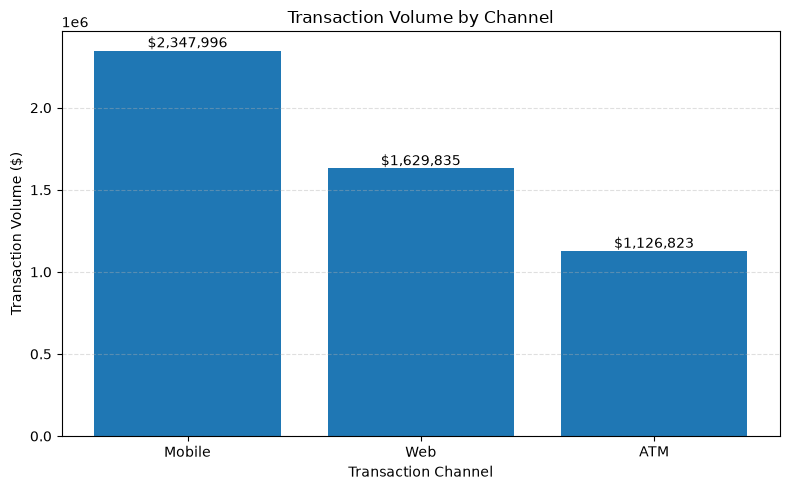

In [59]:
channel_df = channel_df.sort_values(
    by="total_amount",
    ascending=False
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    channel_df["transaction_channel"],
    channel_df["total_amount"]
)

plt.title("Transaction Volume by Channel")
plt.xlabel("Transaction Channel")
plt.ylabel("Transaction Volume ($)")

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../images/transaction_channel.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusion

Mobile banking generated the highest transaction volume, reaching approximately **$2.35 million**, followed by the Web channel with **$1.63 million**. ATM transactions contributed the lowest transaction volume at approximately **$1.13 million**.

These results suggest that customers primarily rely on digital channels, particularly mobile banking, to conduct their financial transactions. The strong adoption of mobile services highlights the importance of continuing to invest in mobile platform reliability, security, and user experience, while maintaining ATM services as a complementary access channel.

# Account Analysis

## KPI 6. Average Balance by Account Type

This analysis compares the average account balance across different account types. Evaluating average balances helps identify which products hold the greatest customer funds and provides insight into the financial characteristics of each account category.

Load data

In [51]:
account_df = run_query("average_balance_by_account_type")
account_df

,account_type,amount_average
0,Savings,25409.503485
1,Checking,22049.453429
2,Credit,-1045.461930


Visualization

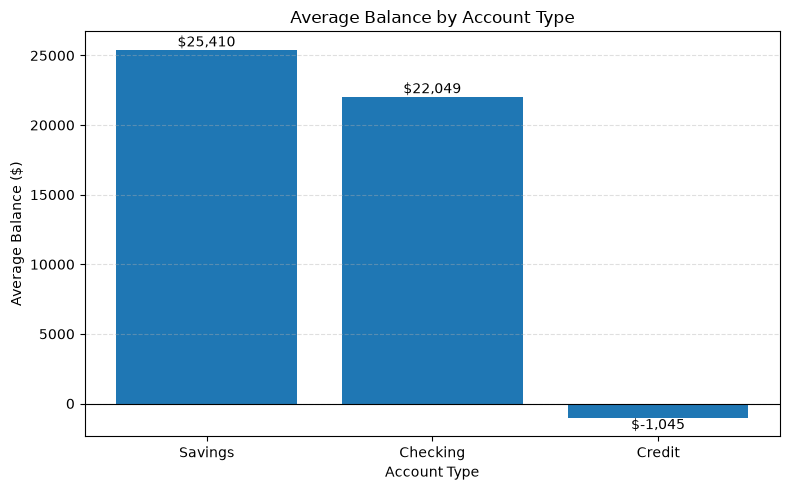

In [52]:
account_df = account_df.sort_values(
    by="amount_average",
    ascending=False
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    account_df["account_type"],
    account_df["amount_average"]
)

plt.title("Average Balance by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Average Balance ($)")

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"${value:,.0f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=10
    )

plt.axhline(0, color="black", linewidth=0.8)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Conclusion

Savings accounts have the highest average balance at approximately **$25.4 thousand**, followed by checking accounts with an average balance of around **$22.0 thousand**. In contrast, credit accounts show an average balance of approximately **-$1.0 thousand**, reflecting that customers typically maintain outstanding credit balances rather than positive deposits.

These results indicate that savings and checking accounts are the primary repositories of customer funds, while credit accounts represent borrowing activity instead of accumulated assets. This distinction is expected in banking operations and highlights the different financial roles of each account type.

## KPI 7. Active Accounts Percentage

This analysis measures the proportion of active accounts within the bank's customer portfolio. Monitoring account activity provides insight into customer engagement and helps assess how effectively the bank retains active relationships with its clients.

Load data

In [53]:
active_df = run_query("active_accounts_percentage")
active_df

,total_accounts,active_accounts,active_percentage
0,193,86,44.56


Visualization

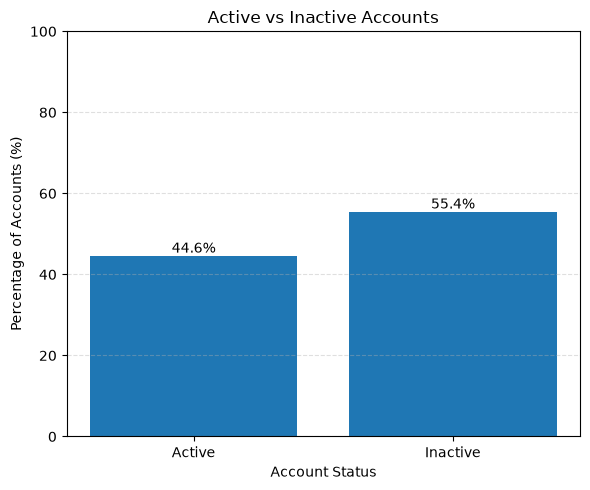

In [60]:
active_percentage = active_df.loc[0, "active_percentage"]
inactive_percentage = 100 - active_percentage

status_df = pd.DataFrame({
    "Status": ["Active", "Inactive"],
    "Percentage": [active_percentage, inactive_percentage]
})

plt.figure(figsize=(6,5))

bars = plt.bar(
    status_df["Status"],
    status_df["Percentage"]
)

plt.title("Active vs Inactive Accounts")
plt.xlabel("Account Status")
plt.ylabel("Percentage of Accounts (%)")

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../images/active_accounts.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusion

Out of **193 total accounts**, **86 are currently active**, resulting in an active account rate of **44.56%**. Consequently, more than half of the accounts are inactive, indicating a relatively low level of customer engagement.

This result suggests an opportunity for the bank to strengthen customer retention and reactivation strategies. Increasing account activity through personalized offers, digital engagement initiatives, or loyalty programs could improve customer participation and maximize the value of the existing customer base.

# Risk and Operational Analysis

## KPI 8. Failed Transactions by Product Category

This analysis examines the number of failed transactions across product categories. Monitoring failed transactions helps identify operational issues, assess transaction reliability, and detect whether specific products require process improvements or additional monitoring.

Load data

In [55]:
failed_df = run_query("failed_transactions_by_product_category")
failed_df

,product_category_name,product_category_id,total_counts
0,B,2,159
1,A,1,155
2,C,3,153


Visualization

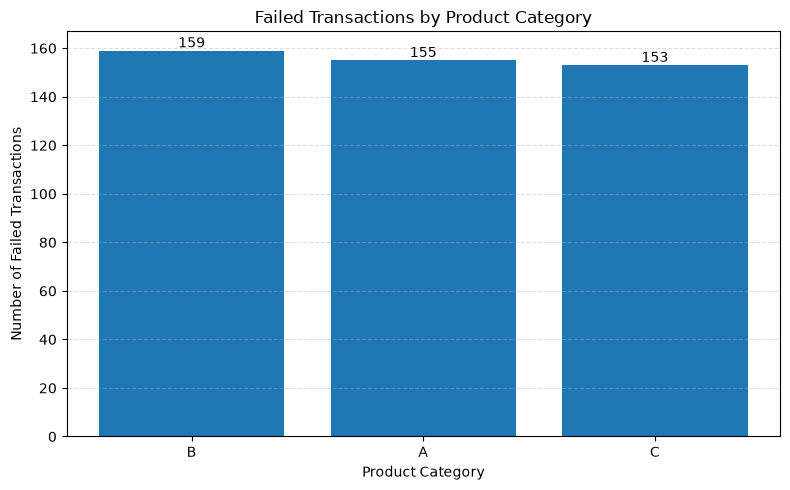

In [61]:
failed_df = failed_df.sort_values(
    by="total_counts",
    ascending=False
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    failed_df["product_category_name"],
    failed_df["total_counts"]
)

plt.title("Failed Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Failed Transactions")

for bar in bars:
    value = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../images/failed_transactions.png", dpi=300, bbox_inches="tight")
plt.show()

## Conclusion

Product Category **B** recorded the highest number of failed transactions (**159**), followed closely by Category **A** (**155**) and Category **C** (**153**). The difference between categories is minimal, indicating that transaction failures are relatively evenly distributed across the bank's product portfolio.

Since no single product category exhibits a significantly higher failure rate, the results suggest that operational issues are not concentrated within a specific product. Further analysis of transaction channels, processing systems, or failure reasons would be necessary to identify the underlying causes and develop targeted improvement strategies.

# Executive Summary

This project analyzed banking transactions to evaluate regional performance, customer engagement, product contribution, transaction channels, and operational efficiency.

### Key Findings

- **Regional Performance:** Colorado generated the highest transaction volume, while Massachusetts had the largest customer base. This indicates that customer volume alone does not determine overall transaction performance.

- **Product Performance:** Product Category A generated the highest transaction volume, although the three product categories contributed similar amounts, suggesting a well-balanced product portfolio.

- **Customer Engagement:** Only 44.56% of accounts were active, highlighting an opportunity to improve customer retention and increase account utilization.

- **Channel Performance:** Mobile banking represented the largest transaction channel, demonstrating strong customer adoption of digital banking services.

- **Account Analysis:** Savings accounts maintained the highest average balances, while credit accounts showed negative average balances, reflecting their role as borrowing products.

- **Operational Performance:** Failed transactions were distributed almost evenly across product categories, indicating that operational issues are not concentrated in a single product line.

### Final Recommendation

The analysis suggests that the bank should prioritize customer engagement initiatives, continue investing in digital banking channels, and monitor transaction performance over time to identify emerging trends. Additionally, maintaining operational consistency across all product categories will help ensure reliable customer service and support future business growth.